# Лабораторная работа — Вариант 13

- **Ячейка 1** — диаграмма рассеяния с линией регрессии и центром рассеяния
- **Ячейка 2** — фактические и предсказанные значения (отклонения МНК)
- **Ячейка 3** — график остатков

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Вариант 13: X — строка 13, Y — строка 14
X = np.array([1.0, 5.2, 3.9, 4.8, 5.1, 6.2, 7.1, 3.6, 5.1, 5.8])
Y = np.array([-0.8, 3.5, 4.3, 4.1, 4.7, 5.9, 7.5, 3.2, 4.8, 6.1])
n = len(X)

mx, my = X.mean(), Y.mean()
Dx = (X**2).mean() - mx**2
sx = np.sqrt(Dx); sy = np.sqrt(Y.var())
cov = (X*Y).mean() - mx*my
r, _ = stats.pearsonr(X, Y)

b = cov / Dx            # наклон
a = my - b*mx           # свободный член
Yhat = a + b*X          # предсказанные значения
resid = Y - Yhat        # остатки

BLUE='#2E5C8A'; ORANGE='#E07B39'; GREEN='#3A8C5C'; GRAY='#6b7280'
print(f"r = {r:.4f},  R^2 = {r**2:.4f}")
print(f"Регрессия: Y = {a:.3f} + {b:.3f} * X")
print(f"Центр рассеяния: ({mx:.2f}; {my:.2f})")

r = 0.9575,  R^2 = 0.9169
Регрессия: Y = -1.732 + 1.268 * X
Центр рассеяния: (4.78; 4.33)


## График 1. Диаграмма рассеяния и линия регрессии

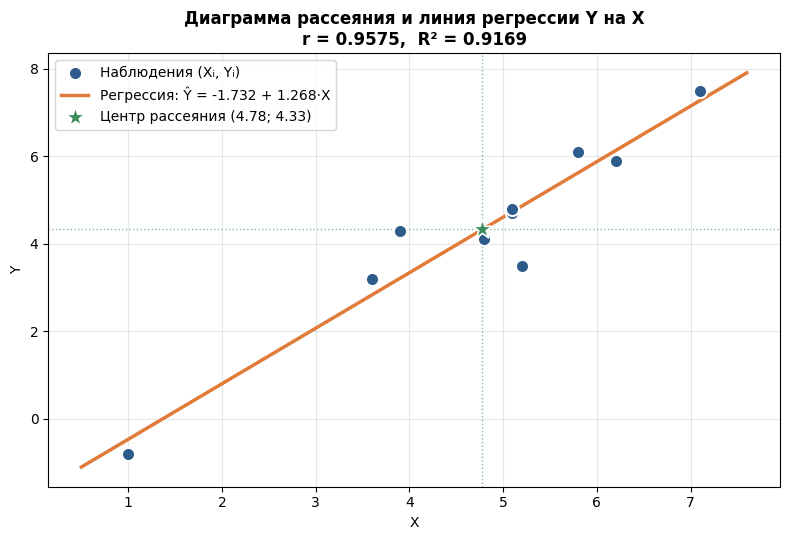

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(X, Y, s=90, color=BLUE, edgecolor='white', linewidth=1.5, zorder=5,
           label='Наблюдения (Xᵢ, Yᵢ)')
xs = np.linspace(X.min()-0.5, X.max()+0.5, 100)
ax.plot(xs, a + b*xs, color=ORANGE, linewidth=2.5, zorder=4,
        label=f'Регрессия: Ŷ = {a:.3f} + {b:.3f}·X')
ax.scatter([mx], [my], s=220, marker='*', color=GREEN, edgecolor='white',
           linewidth=1.2, zorder=6, label=f'Центр рассеяния ({mx:.2f}; {my:.2f})')
ax.axvline(mx, color=GREEN, ls=':', lw=1, alpha=0.6)
ax.axhline(my, color=GREEN, ls=':', lw=1, alpha=0.6)
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title(f'Диаграмма рассеяния и линия регрессии Y на X\nr = {r:.4f},  R² = {r**2:.4f}',
             fontweight='bold')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## График 2. Фактические и предсказанные значения

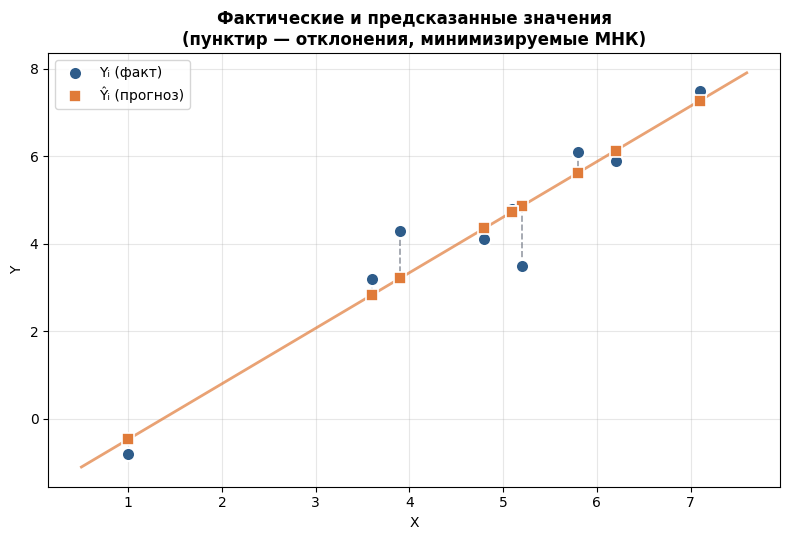

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(X, Y, s=90, color=BLUE, edgecolor='white', linewidth=1.5, zorder=5,
           label='Yᵢ (факт)')
ax.scatter(X, Yhat, s=70, color=ORANGE, marker='s', edgecolor='white',
           linewidth=1.2, zorder=5, label='Ŷᵢ (прогноз)')
xs = np.linspace(X.min()-0.5, X.max()+0.5, 100)
ax.plot(xs, a + b*xs, color=ORANGE, lw=2, alpha=0.7, zorder=3)
for xi, yi, yh in zip(X, Y, Yhat):
    ax.plot([xi, xi], [yi, yh], color=GRAY, lw=1.2, ls='--', alpha=0.7, zorder=2)
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Фактические и предсказанные значения\n'
             '(пунктир — отклонения, минимизируемые МНК)', fontweight='bold')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## График 3. График остатков

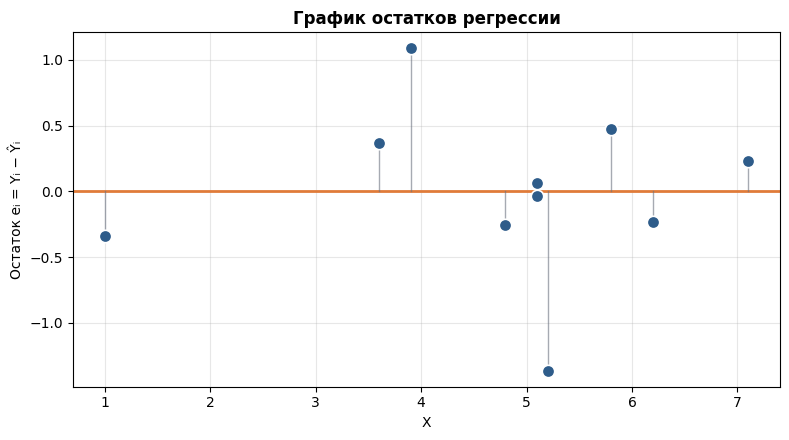

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(X, resid, s=80, color=BLUE, edgecolor='white', linewidth=1.2, zorder=5)
ax.axhline(0, color=ORANGE, lw=2)
for xi, ri in zip(X, resid):
    ax.plot([xi, xi], [0, ri], color=GRAY, lw=1, alpha=0.6)
ax.set_xlabel('X'); ax.set_ylabel('Остаток eᵢ = Yᵢ − Ŷᵢ')
ax.set_title('График остатков регрессии', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()